# 03 — Out-of-sample tests, robustness and multiple testing

All numbers below are produced by `scripts/run_all.py`; this notebook reads its tables so it runs in seconds. The in-sample period is the FF93 window (1963-07 to 1991-12); out-of-sample is everything after it — data neither Fama and French nor the momentum literature could have seen when the factors were proposed.

In [1]:
import numpy as np, pandas as pd
from IPython.display import Image, display
from factor_neutrality import data, factors, regression as rg, strategy as st, performance as pf
pd.set_option("display.float_format", "{:.3f}".format)
pd.set_option("display.width", 160)
ROOT = __import__("pathlib").Path.cwd().parent
TAB, FIG = ROOT / "results" / "tables", ROOT / "results" / "figures"


## In-sample vs. out-of-sample alpha

In [2]:
pd.read_csv(TAB / 'T12_is_vs_oos.csv', index_col=[0,1,2]).loc[['IMOM gross', 'Small-value tilt']]

alpha (%/yr)     t  adj R2       N
Strategy         Model   Period                                           
IMOM gross       CAPM    In-sample            11.789 4.337  -0.002 342.000
                         Out-of-sample         7.748 2.940   0.025 416.000
                         Full                  9.396 4.905   0.010 758.000
                 FF3     In-sample            13.273 5.106   0.028 342.000
                         Out-of-sample         8.883 3.456   0.073 416.000
                         Full                 10.784 5.752   0.047 758.000
                 FF3+UMD In-sample             1.430 0.842   0.682 342.000
                         Out-of-sample         1.867 1.310   0.667 416.000
                         Full                  2.315 2.088   0.665 758.000
                 FF5+UMD In-sample             1.824 0.981   0.681 342.000
                         Out-of-sample         2.261 1.601   0.668 416.000
                         Full                  2.763 2.464   0.668 758.000
Small-value tilt CAPM    In-sample             6.458 2.420   0.643 342.000
                         Out-of-sample         5.206 1.708   0.517 416.000
                         Full                  5.692 2.771   0.575 758.000
                 FF3     In-sample             0.701 0.909   0.964 342.000
                         Out-of-sample         3.602 3.014   0.865 416.000
                         Full                  2.162 2.895   0.908 758.000
                 FF3+UMD In-sample             0.513 0.605   0.964 342.000
                         Out-of-sample         3.732 3.342   0.865 416.000
                         Full                  2.199 3.103   0.907 758.000
                 FF5+UMD In-sample             0.051 0.058   0.963 342.000
                         Out-of-sample         3.648 3.432   0.860 416.000
                         Full                  2.031 2.874   0.905 758.000

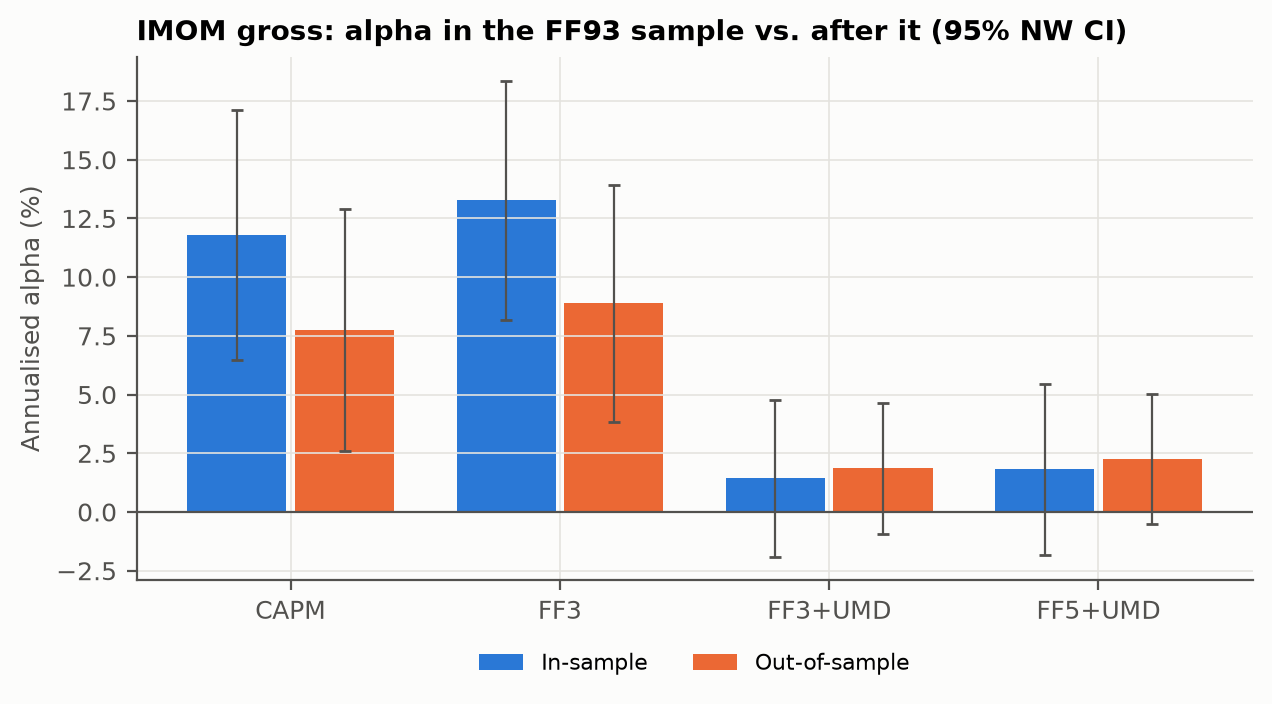

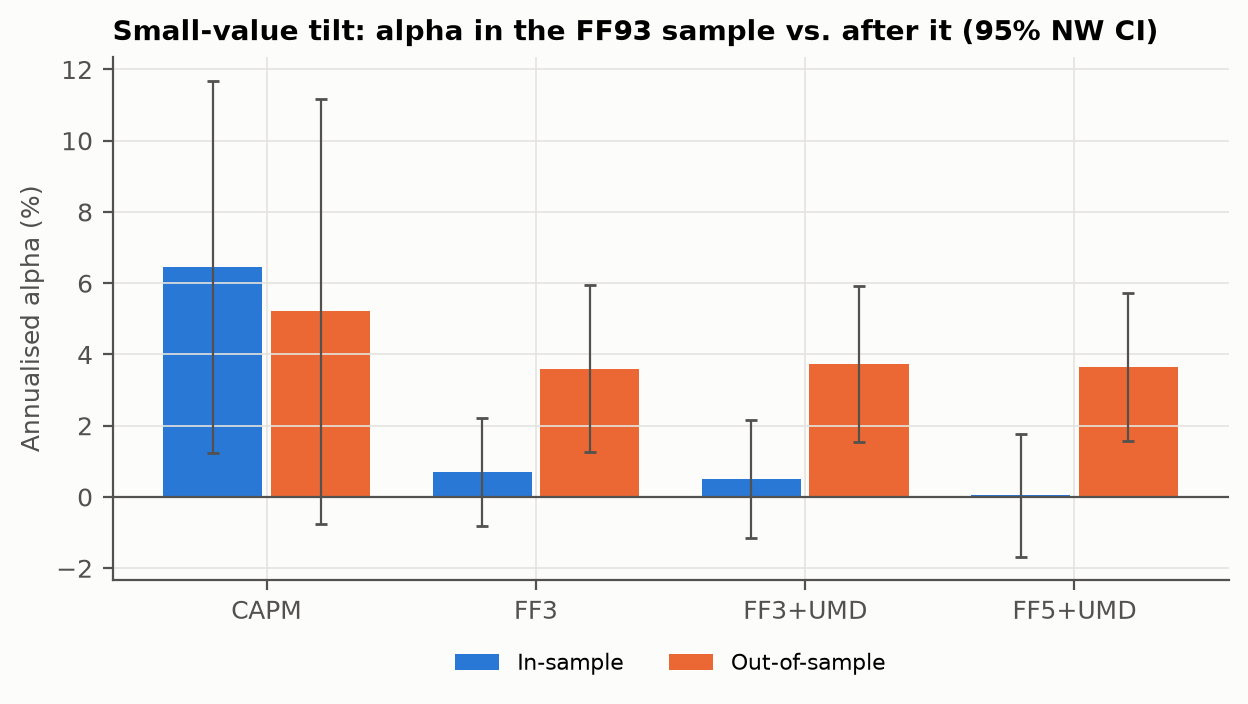

In [3]:
display(Image(FIG / 'F20_is_vs_oos_imom.png')); display(Image(FIG / 'F20_is_vs_oos_smallvalue.png'))

## Parameter grid: chosen in-sample, judged out-of-sample

16 variants (lookback × skip × number of industries). The deflated Sharpe ratio (Bailey & López de Prado 2014) asks whether the best in-sample Sharpe beats what the best of 16 *skill-less* trials would deliver.

In [4]:
pd.read_csv(TAB / 'T14_parameter_grid.csv', index_col=[0,1,2])

Sharpe IS  Sharpe OOS  alpha IS   t IS  alpha OOS  t OOS
lookback skip n                                                           
3        0    5       0.484       0.301     4.325  1.246      5.781  1.688
              10      0.575       0.227     3.666  1.398      3.292  1.479
         1    5       0.444       0.155     1.689  0.513      1.116  0.325
              10      0.422       0.146    -0.343 -0.140      1.020  0.442
6        0    5       0.626       0.276     4.668  1.565      2.278  0.701
              10      0.750       0.220     4.011  1.879      0.686  0.291
         1    5       0.527       0.296     0.266  0.096      1.246  0.418
              10      0.514       0.257    -0.690 -0.341      0.083  0.044
9        0    5       0.762       0.336     5.126  1.692      2.494  0.868
              10      0.798       0.383     2.876  1.389      2.634  1.421
         1    5       0.500       0.351    -1.500 -0.500      2.228  0.883
              10      0.606       0.368    -1.000 -0.518      1.524  0.889
12       0    5       0.803       0.473     3.511  1.230      6.188  2.230
              10      0.888       0.397     3.158  1.523      2.927  1.963
         1    5       0.615       0.376    -0.032 -0.013      2.966  1.173
              10      0.813       0.379     1.824  0.981      2.261  1.601

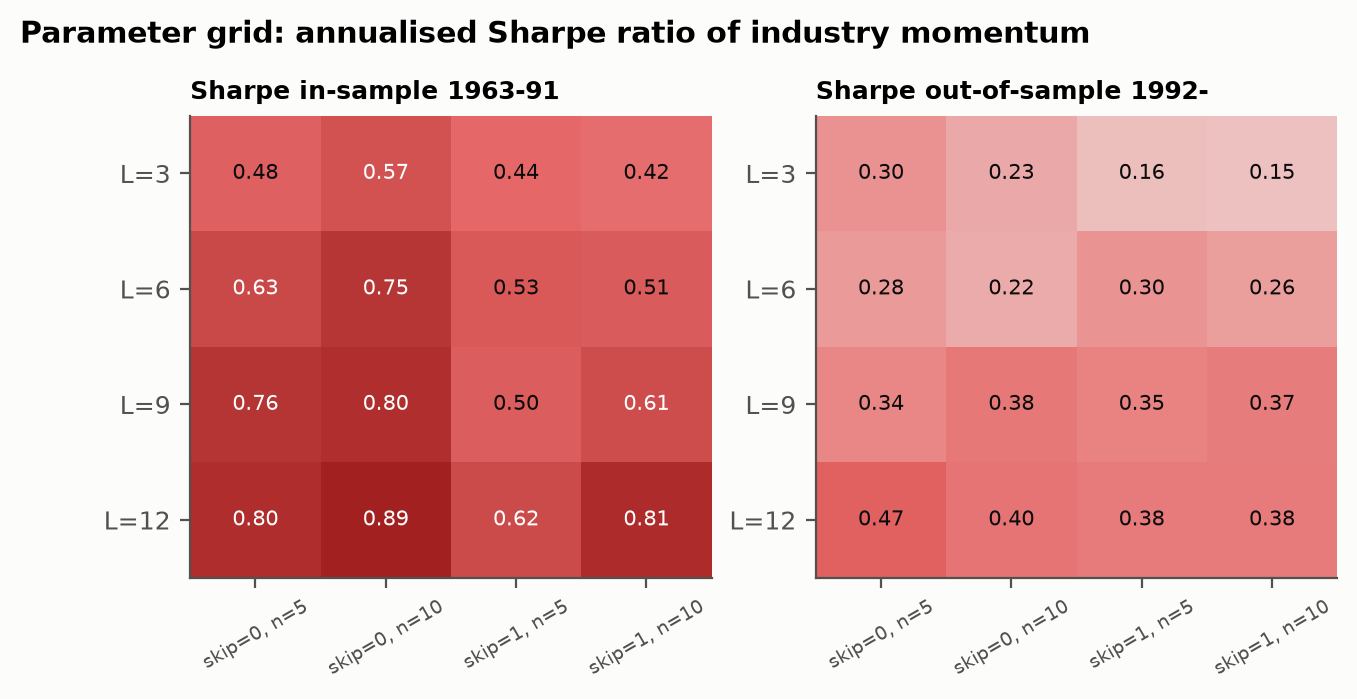

In [5]:
display(Image(FIG / 'F21_parameter_grid.png'))

## Transaction costs

In [6]:
pd.read_csv(TAB / 'T15_transaction_costs.csv', index_col=0)

,Mean (%/yr),Sharpe,CAPM alpha,CAPM t,FF5+UMD alpha,FF5+UMD t
cost (bp one-way),,,,,,
0,8.629,0.561,9.396,4.905,2.763,2.464
10,7.582,0.493,8.351,4.346,1.716,1.525
25,6.011,0.390,6.783,3.513,0.145,0.128
50,3.393,0.220,4.171,2.142,-2.473,-2.162
75,0.775,0.050,1.559,0.793,-5.091,-4.396
100,-1.843,-0.119,-1.054,-0.531,-7.709,-6.563


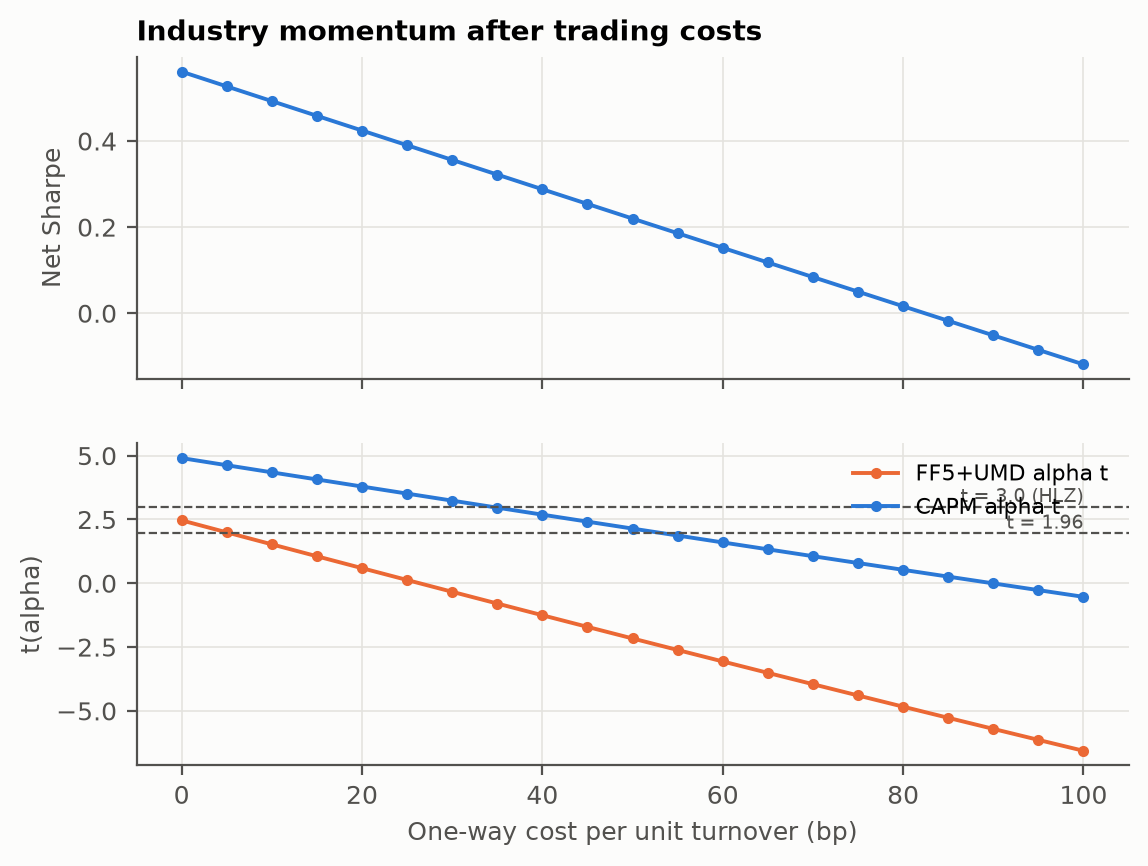

In [7]:
display(Image(FIG / 'F22_transaction_costs.png'))

## Regimes (bear/high-vol labels are ex-ante; NBER recessions are ex-post and descriptive only)

In [8]:
pd.read_csv(TAB / 'T18_regimes.csv', index_col=0)

,Months,Mean (%/yr),Sharpe,FF3+UMD alpha,t,Mkt-RF,SMB,HML,UMD
Bear market (ex-ante): yes,175.000,4.749,0.223,5.923,1.976,-0.014,-0.158,0.084,0.817
Bear market (ex-ante): no,559.000,10.013,0.752,1.681,1.477,0.053,-0.022,-0.040,0.854
High volatility (ex-ante): yes,376.000,6.156,0.340,3.049,1.695,0.015,-0.049,-0.042,0.845
High volatility (ex-ante): no,311.000,11.211,0.914,0.924,0.657,0.074,-0.097,0.065,0.906
NBER recession (ex-post): yes,85.000,7.233,0.290,7.867,1.509,0.021,-0.246,-0.090,0.870
NBER recession (ex-post): no,673.000,8.806,0.641,1.498,1.370,0.056,-0.013,0.017,0.846


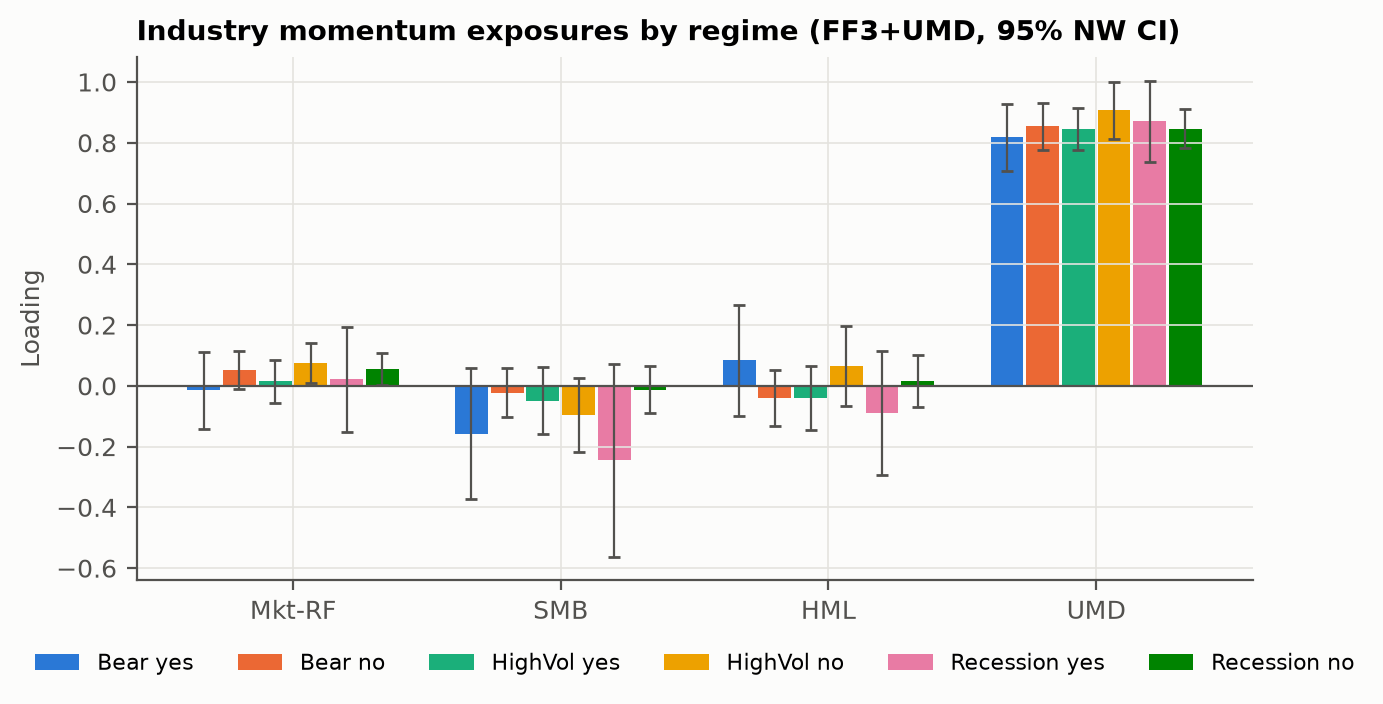

In [9]:
display(Image(FIG / 'F24_regime_exposures.png'))

## Multiple testing

Every alpha test run on industry-momentum variants is recorded, then corrected with Holm's step-down procedure (family-wise error 5%) and compared with the Harvey–Liu–Zhu t > 3 threshold.

In [10]:
mt = pd.read_csv(TAB / 'T17_multiple_testing.csv', index_col=0)
umd = mt.index.str.contains('UMD')
print(f"{len(mt)} tests; with UMD in the benchmark: {umd.sum()} tests, {(mt.loc[umd,'t']>1.96).sum()} with t>1.96, "
      f"{(mt.loc[umd,'t']>3).sum()} with t>3, {(mt.loc[umd,'Holm p']<0.05).sum()} significant after Holm")

90 tests; with UMD in the benchmark: 62 tests, 9 with t>1.96, 0 with t>3, 0 significant after Holm


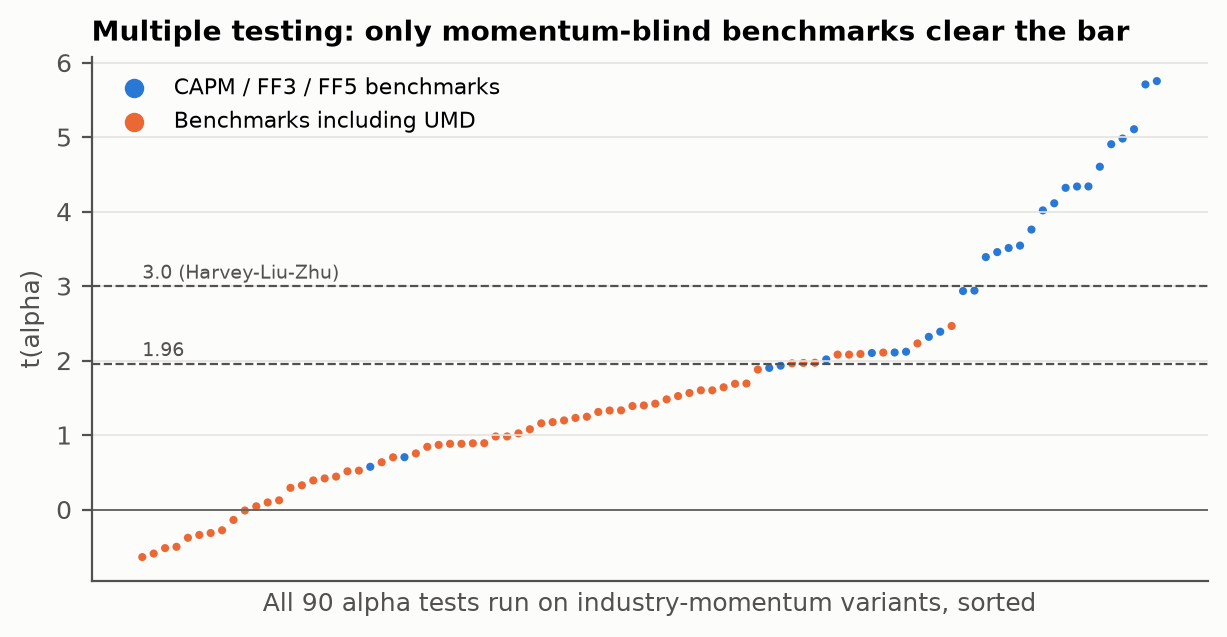

In [11]:
display(Image(FIG / 'F23_multiple_testing.png'))

## International: is the small-value premium factor exposure abroad?

In [12]:
pd.read_csv(TAB / 'T19_international_smallvalue.csv', index_col=0)

,Months,Mean (%/yr),CAPM alpha,CAPM t,GRS CAPM,GRS CAPM p,mean|a| CAPM (%/mo),FF3 alpha,FF3 t,GRS FF3,GRS FF3 p,mean|a| FF3 (%/mo),SMB beta,HML beta
North America,434.000,12.915,3.677,1.488,3.472,0.000,0.142,3.916,5.176,3.560,0.000,0.106,0.986,0.574
Europe,434.000,9.078,3.535,2.041,3.042,0.000,0.116,2.335,3.820,2.760,0.000,0.090,0.923,0.420
Japan,434.000,6.765,4.454,1.986,1.542,0.048,0.158,2.604,3.837,1.205,0.229,0.082,0.975,0.445
Asia Pacific ex Japan,434.000,13.928,6.996,2.516,4.076,0.000,0.223,7.037,5.225,3.567,0.000,0.202,1.187,0.532
Developed,434.000,10.909,5.337,3.070,5.539,0.000,0.144,4.499,7.255,5.218,0.000,0.109,0.996,0.461


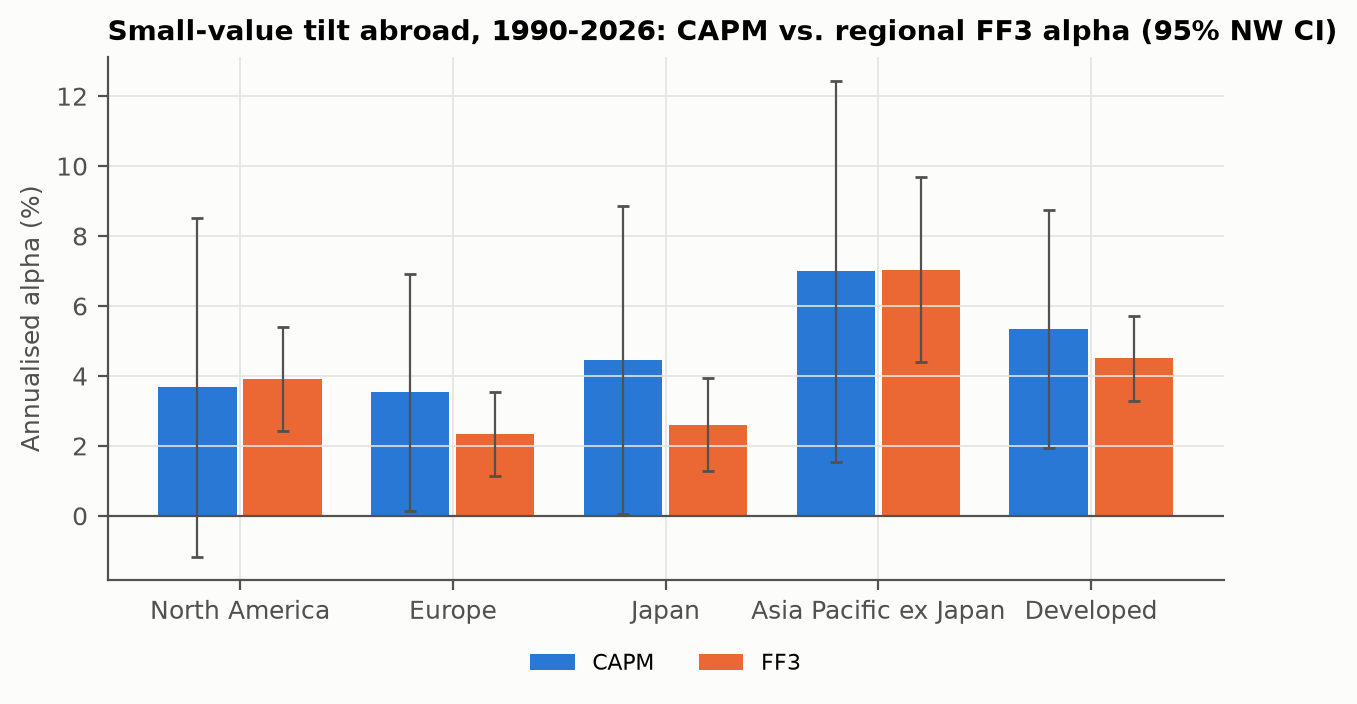

In [13]:
display(Image(FIG / 'F25_international.png'))